### Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
from scipy import stats

# ── Load ──
micro = pd.read_csv("../data/micro_clean.csv")
large = pd.read_csv("../data/large_clean.csv")

# ── Filter micro ──
micro = micro[micro['view_count'] > 0]
micro = micro[micro['subscriber_count'] < 10000]
micro = micro[micro['like_rate'] <= 1]

# ── Filter large ──
large = large[large['view_count'] > 0]
large = large[large['subscriber_count'] >= 10000]
large = large[large['like_rate'] <= 1]

# ── Parse hashtags ──
def parse_micro_hashtags(row):
    t = str(row['hashtags_from_title']).split('|||')
    d = str(row['hashtags_from_desc']).split('|||')
    return list(set([
        x.strip().lower().lstrip('#')
        for x in t + d
        if x.strip() and x.strip() != 'nan'
    ]))

def parse_large_hashtags(x):
    x = str(x)
    if x in ['nan', '[]', '']: return []
    x = x.strip("[]").replace("'", "").replace('"', '')
    return list(set([t.strip().lower() for t in x.split(',') if t.strip()]))

micro['hashtag_list'] = micro.apply(parse_micro_hashtags, axis=1)
large['hashtag_list'] = large['all_hashtags'].apply(parse_large_hashtags)

print("Micro loaded:", len(micro), "rows")
print("Large loaded:", len(large), "rows")
print("Micro hashtag coverage:", (micro['hashtag_list'].apply(len) > 0).sum(), "videos with hashtags")
print("Large hashtag coverage:", (large['hashtag_list'].apply(len) > 0).sum(), "videos with hashtags")

Micro loaded: 1035 rows
Large loaded: 1174 rows
Micro hashtag coverage: 864 videos with hashtags
Large hashtag coverage: 731 videos with hashtags


### 5.1 Two-Dimensional Framework (Views x Like Rate)

Quadrant distribution:
quadrant
Niche            292
Exposure Trap    292
Golden           226
Ineffective      225

Median views threshold: 742
Median like rate threshold: 0.015


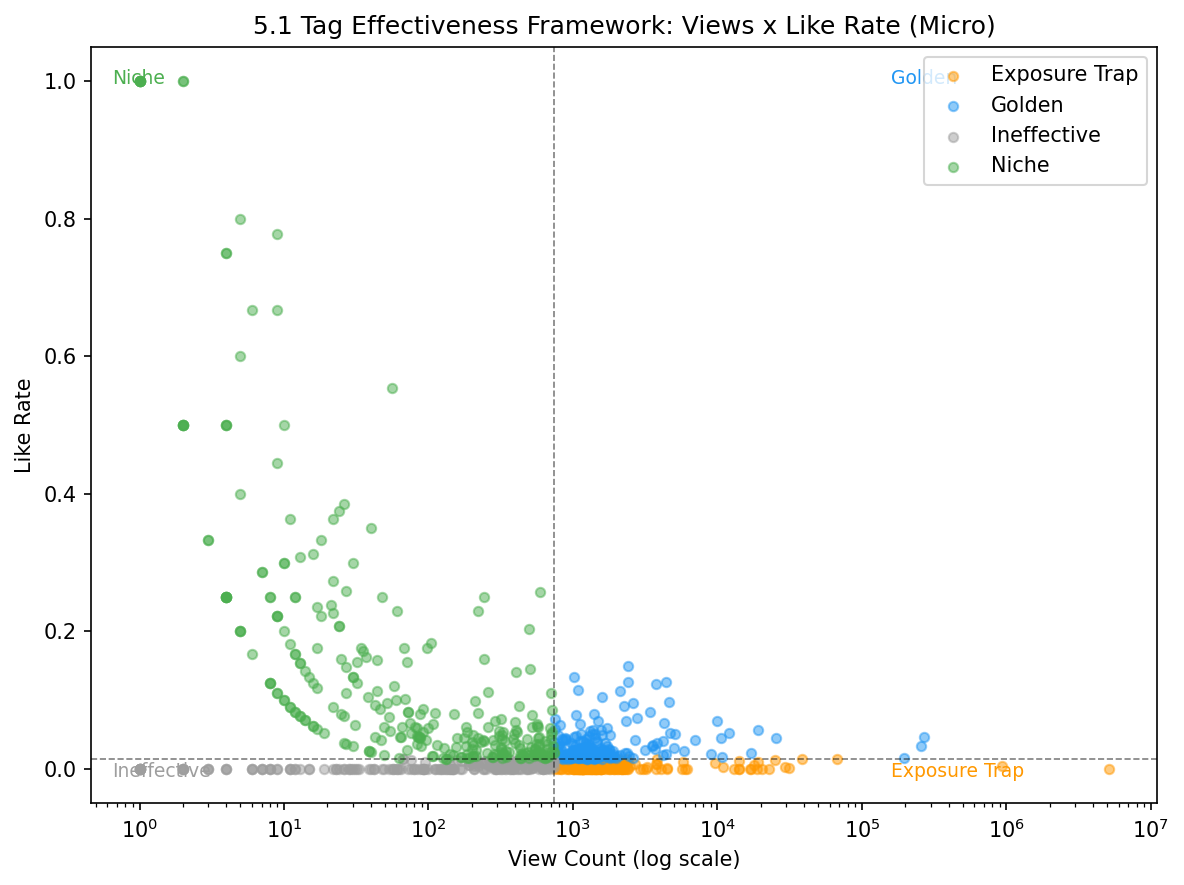

Saved: 5_1_quadrant_framework.png


In [2]:
# Use micro dataset for quadrant analysis
med_views = micro['view_count'].median()
med_lr    = micro['like_rate'].median()

def get_quadrant(row):
    high_v = row['view_count'] >= med_views
    high_l = row['like_rate']  >= med_lr
    if high_v and high_l:        return 'Golden'
    elif high_v and not high_l:  return 'Exposure Trap'
    elif not high_v and high_l:  return 'Niche'
    else:                        return 'Ineffective'

micro['quadrant'] = micro.apply(get_quadrant, axis=1)

# Quadrant distribution
quad_dist = micro['quadrant'].value_counts()
print("Quadrant distribution:")
print(quad_dist.to_string())
print(f"\nMedian views threshold: {int(med_views)}")
print(f"Median like rate threshold: {round(med_lr, 4)}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

colors = {
    'Golden':        '#2196F3',
    'Niche':         '#4CAF50',
    'Exposure Trap': '#FF9800',
    'Ineffective':   '#9E9E9E'
}

for quad, group in micro.groupby('quadrant'):
    ax.scatter(group['view_count'], group['like_rate'],
               c=colors[quad], label=quad, alpha=0.5, s=20)

ax.axvline(med_views, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(med_lr,    color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xscale('log')
ax.set_xlabel('View Count (log scale)')
ax.set_ylabel('Like Rate')
ax.set_title('5.1 Tag Effectiveness Framework: Views x Like Rate (Micro)')
ax.legend(loc='upper right')

# Add quadrant labels
ax.text(0.02, 0.97, 'Niche',         transform=ax.transAxes, fontsize=9, color='#4CAF50', va='top')
ax.text(0.75, 0.97, 'Golden',        transform=ax.transAxes, fontsize=9, color='#2196F3', va='top')
ax.text(0.75, 0.03, 'Exposure Trap', transform=ax.transAxes, fontsize=9, color='#FF9800', va='bottom')
ax.text(0.02, 0.03, 'Ineffective',   transform=ax.transAxes, fontsize=9, color='#9E9E9E', va='bottom')

plt.tight_layout()
plt.savefig('5_1_quadrant_framework.png', bbox_inches='tight')
plt.show()
print("Saved: 5_1_quadrant_framework.png")

 “理想情况下，标签效果应分别从可发现性（曝光量）和受众契合度（点赞率）两个方面进行评估。然而，由于缺乏曝光量数据，本研究使用浏览量作为综合指标，并在后续分析中主要关注点赞率作为关键绩效指标。”
Ideally, tag effectiveness should be evaluated separately on discoverability (impressions) and audience fit (like rate). However, due to the absence of impression data, this study uses views as a combined proxy, and focuses primarily on like rate as the key performance indicator in subsequent analysis.

### 5.2 Which tags perform Best?（Tag Type Distribution: Top 15 vs Bottom 15）

### 5.2.1 like rate VS view

#### Like rate

Top 15 tags:
           tag  count  mean_lr                type
    simplelife     10   0.1577            Identity
    firstvideo     10   0.1513            Identity
 youtubegrowth     12   0.1290            Identity
  smallcreator     13   0.1153            Identity
        gaming     15   0.1114    Content-specific
  dailyroutine     50   0.1055    Content-specific
  adayinmylife     16   0.0921    Content-specific
            yt     19   0.0913           Ambiguous
   dayinmylife     33   0.0876    Content-specific
    viralvideo     71   0.0834      Format-chasing
          like     15   0.0834           Ambiguous
 lifestylevlog     30   0.0833    Content-specific
    reelsindia     11   0.0825    Content-specific
         india     15   0.0823 Audience-descriptor
morningroutine     27   0.0812    Content-specific

Bottom 15 tags:
          tag  count  mean_lr                type
 studyroutine     12   0.0073 Audience-descriptor
     students     14   0.0079 Audience-descriptor
  sh

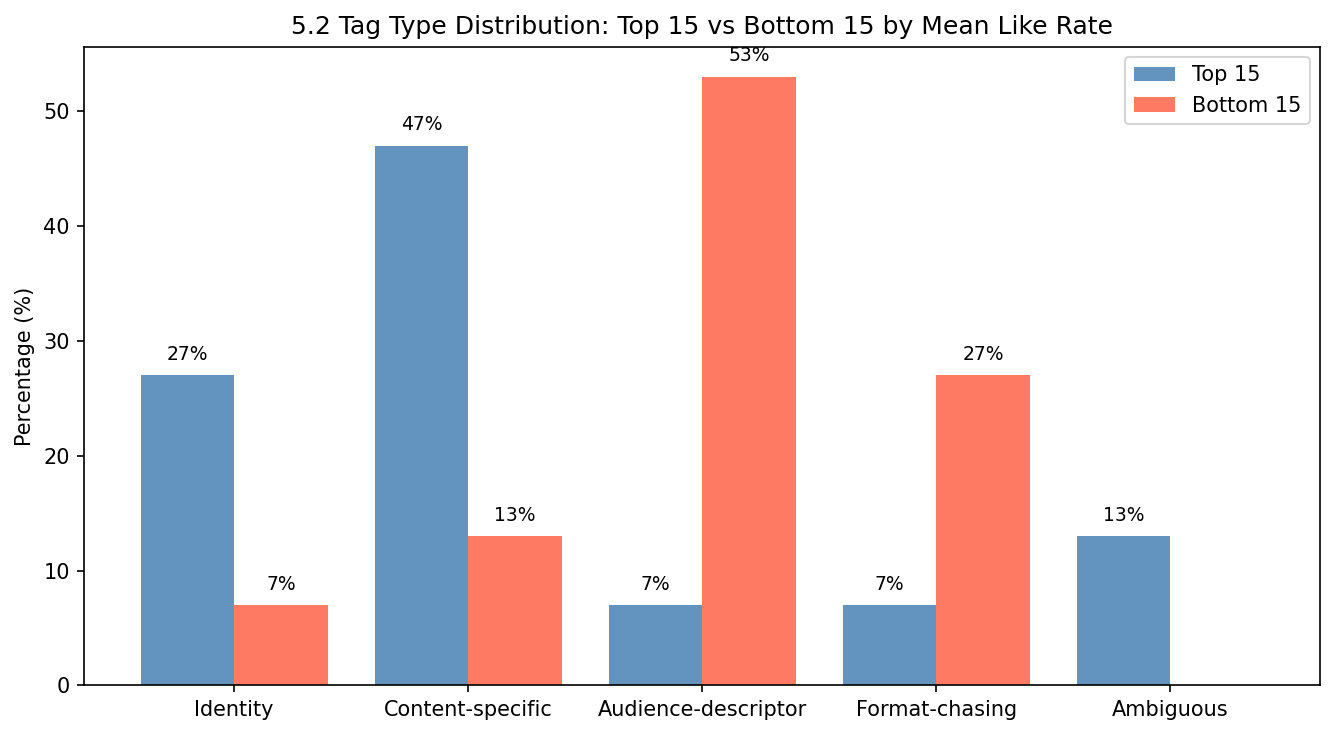

Saved: 5_2_tag_type_distribution.png


In [4]:
# ── Build tag performance table ──
tag_perf = {}
for _, row in micro.iterrows():
    for t in row['hashtag_list']:
        tag_perf.setdefault(t, []).append(row['like_rate'])

tag_df = pd.DataFrame([
    (tag, len(rates), round(np.mean(rates), 4), round(np.median(rates), 4))
    for tag, rates in tag_perf.items() if len(rates) >= 10
], columns=['tag', 'count', 'mean_lr', 'median_lr'])

top15 = tag_df.nlargest(15, 'mean_lr').copy()
bot15 = tag_df.nsmallest(15, 'mean_lr').copy()

# ── Manual type labeling ──
top15_types = {
    'simplelife': 'Identity', 'firstvideo': 'Identity',
    'youtubegrowth': 'Identity', 'smallcreator': 'Identity',
    'gaming': 'Content-specific', 'dailyroutine': 'Content-specific',
    'adayinmylife': 'Content-specific', 'yt': 'Ambiguous',
    'dayinmylife': 'Content-specific', 'viralvideo': 'Format-chasing',
    'like': 'Ambiguous', 'lifestylevlog': 'Content-specific',
    'reelsindia': 'Content-specific', 'india': 'Audience-descriptor',
    'morningroutine': 'Content-specific'
}

bot15_types = {
    'studyroutine': 'Audience-descriptor', 'students': 'Audience-descriptor',
    'shortsvideo': 'Format-chasing', 'productive': 'Audience-descriptor',
    'studytips': 'Audience-descriptor', 'asmr': 'Content-specific',
    'minivlogs': 'Format-chasing', 'college': 'Audience-descriptor',
    'trendingvideo': 'Format-chasing', 'shortsviral': 'Format-chasing',
    'foodie': 'Audience-descriptor', 'studyvlog': 'Content-specific',
    'youtuber': 'Identity', 'collegelife': 'Audience-descriptor',
    'studentlife': 'Audience-descriptor'
}

top15['type'] = top15['tag'].map(top15_types)
bot15['type'] = bot15['tag'].map(bot15_types)

# ── Print tables ──
print("Top 15 tags:")
print(top15[['tag', 'count', 'mean_lr', 'type']].to_string(index=False))

print("\nBottom 15 tags:")
print(bot15[['tag', 'count', 'mean_lr', 'type']].to_string(index=False))

# ── Type distribution comparison ──
all_types = ['Identity', 'Content-specific', 'Audience-descriptor', 'Format-chasing', 'Ambiguous']
top_dist = top15['type'].value_counts()
bot_dist = bot15['type'].value_counts()

comp = pd.DataFrame({
    'Top 15': [top_dist.get(t, 0) for t in all_types],
    'Bottom 15': [bot_dist.get(t, 0) for t in all_types]
}, index=all_types)
comp['Top 15 %']    = (comp['Top 15'] / 15 * 100).round(0).astype(int)
comp['Bottom 15 %'] = (comp['Bottom 15'] / 15 * 100).round(0).astype(int)

print("\nType distribution comparison:")
print(comp.to_string())

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(all_types))
bars1 = ax.bar(x - 0.2, comp['Top 15 %'],    width=0.4, label='Top 15',    color='steelblue', alpha=0.85)
bars2 = ax.bar(x + 0.2, comp['Bottom 15 %'], width=0.4, label='Bottom 15', color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_types, fontsize=10)
ax.set_ylabel('Percentage (%)')
ax.set_title('5.2 Tag Type Distribution: Top 15 vs Bottom 15 by Mean Like Rate')
ax.legend()

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{int(bar.get_height())}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{int(bar.get_height())}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('5_2_tag_type_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: 5_2_tag_type_distribution.png")

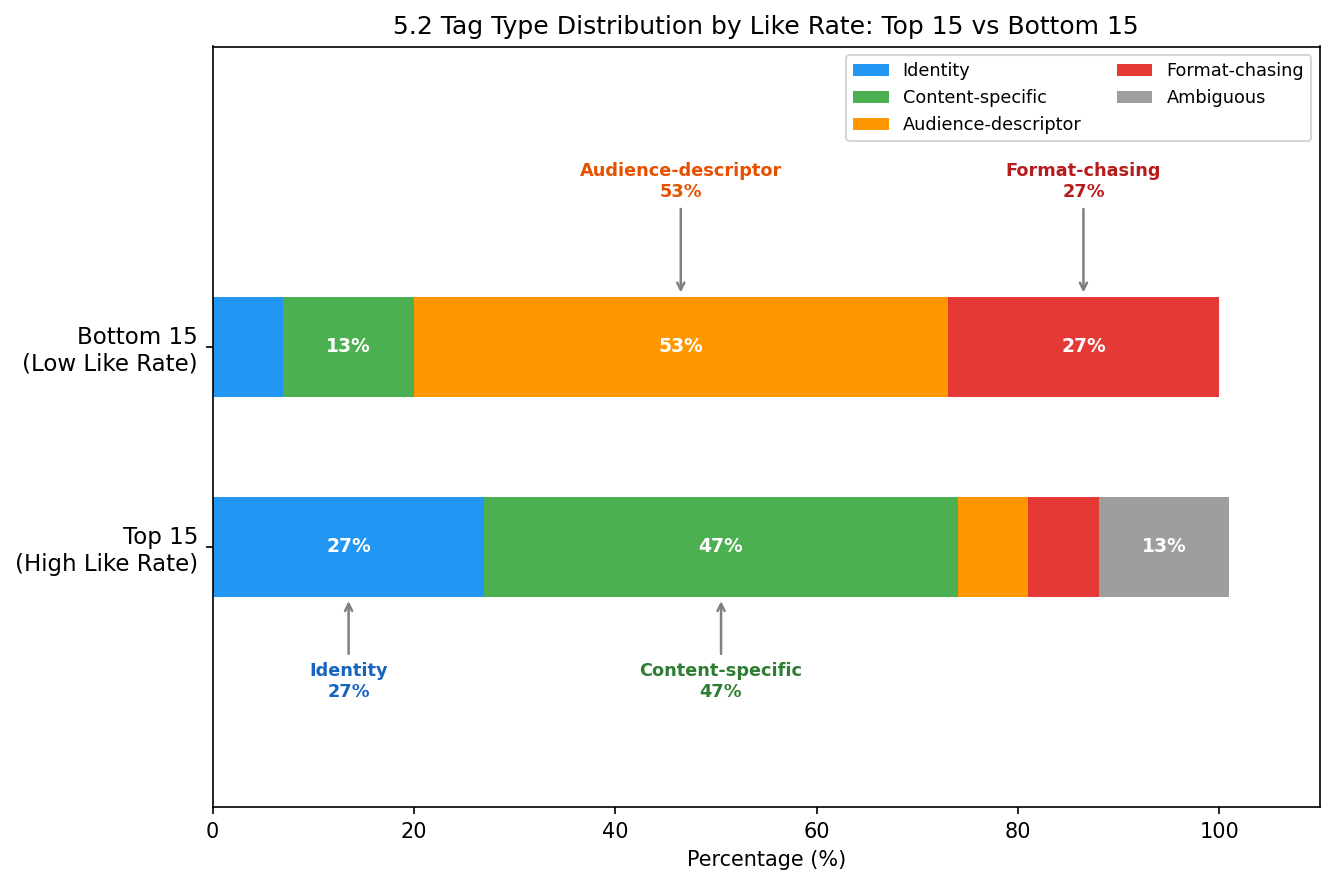

Saved: 5_2_tag_type_stacked_annotated.png


In [28]:
fig, ax = plt.subplots(figsize=(9, 6))

all_types = ['Identity', 'Content-specific', 'Audience-descriptor', 'Format-chasing', 'Ambiguous']
colors    = ['#2196F3', '#4CAF50', '#FF9800', '#E53935', '#9E9E9E']

top_pcts = [comp.loc[t, 'Top 15 %']    for t in all_types]
bot_pcts = [comp.loc[t, 'Bottom 15 %'] for t in all_types]

bar_pos = [0.2, 1.2]
groups = ['Top 15\n(High Like Rate)', 'Bottom 15\n(Low Like Rate)']
data   = [top_pcts, bot_pcts]

top_positions = {}
bot_positions = {}

for i, (group, pcts) in enumerate(zip(groups, data)):
    left = 0
    for j, (pct, color, ttype) in enumerate(zip(pcts, colors, all_types)):
        if pct > 0:
            ax.barh(i, pct, left=left, color=color,
                    label=ttype if i == 0 else "", height=0.5)
            if pct >= 8:
                ax.text(left + pct/2, i, f'{pct}%',
                        ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            center_x = left + pct/2
            if i == 0:
                top_positions[ttype] = (center_x, pct)
            else:
                bot_positions[ttype] = (center_x, pct)
            left += pct

# Top 15 annotations — label BELOW the bar (i=0, pointing down)
for ttype, ann_color in [('Identity', '#1565C0'), ('Content-specific', '#2E7D32')]:
    if ttype in top_positions:
        cx, pct = top_positions[ttype]
        ax.annotate(f'{ttype}\n{pct}%',
                    xy=(cx, -0.25),
                    xytext=(cx, -0.75),
                    ha='center', fontsize=8.5,
                    color=ann_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Bottom 15 annotations — label ABOVE the bar (i=1, pointing up)
for ttype, ann_color in [('Audience-descriptor', '#E65100'), ('Format-chasing', '#B71C1C')]:
    if ttype in bot_positions:
        cx, pct = bot_positions[ttype]
        ax.annotate(f'{ttype}\n{pct}%',
                    xy=(cx, 1.25),
                    xytext=(cx, 1.75),
                    ha='center', fontsize=8.5,
                    color=ann_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.set_yticks([0, 1])
ax.set_yticklabels(groups, fontsize=11)
ax.set_xlabel('Percentage (%)')
ax.set_xlim(0, 110)
ax.set_ylim(-1.3, 2.5)
ax.set_title('5.2 Tag Type Distribution by Like Rate: Top 15 vs Bottom 15')
ax.legend(loc='upper right', fontsize=8.5, ncol=2)

plt.tight_layout()
plt.savefig('5_2_tag_type_stacked_annotated.png', bbox_inches='tight')
plt.show()
print("Saved: 5_2_tag_type_stacked_annotated.png")

#### views

In [26]:
# Build tag performance table with both like_rate and view_count
tag_perf_full = {}
for _, row in micro.iterrows():
    for t in row['hashtag_list']:
        if t not in tag_perf_full:
            tag_perf_full[t] = {'like_rates': [], 'views': []}
        tag_perf_full[t]['like_rates'].append(row['like_rate'])
        tag_perf_full[t]['views'].append(row['view_count'])

tag_df_full = pd.DataFrame([
    (tag, len(v['like_rates']),
     round(np.mean(v['like_rates']), 4),
     round(np.mean(v['views']), 0))
    for tag, v in tag_perf_full.items() if len(v['like_rates']) >= 10
], columns=['tag', 'count', 'mean_lr', 'mean_views'])

# Top 15 and Bottom 15 by views
top15_views = tag_df_full.nlargest(15, 'mean_views').copy()
bot15_views = tag_df_full.nsmallest(15, 'mean_views').copy()

print("Top 15 by mean views:")
print(top15_views[['tag','count','mean_views','mean_lr']].to_string(index=False))
print("\nBottom 15 by mean views:")
print(bot15_views[['tag','count','mean_views','mean_lr']].to_string(index=False))

Top 15 by mean views:
          tag  count  mean_views  mean_lr
youtubegrowth     12     80545.0   0.1290
youtubeshorts    113     46619.0   0.0253
       shorts    264     24172.0   0.0422
          art     10     22173.0   0.0269
    funnyvlog     12      9752.0   0.0309
    minivlogs     10      7816.0   0.0119
trendingvideo     10      7777.0   0.0127
   viralshort     12      6498.0   0.0222
smallyoutuber     50      6377.0   0.0221
     students     14      6128.0   0.0079
        trend     17      5366.0   0.0396
        short     20      4659.0   0.0275
  collegelife     19      4327.0   0.0153
    viralvlog     13      3909.0   0.0427
         live     15      3901.0   0.0420

Bottom 15 by mean views:
         tag  count  mean_views  mean_lr
        mini     11       179.0   0.0695
smallcreator     13       257.0   0.1153
  firstvideo     10       344.0   0.1513
  newchannel     11       369.0   0.0702
     support     12       409.0   0.0493
       video     14       410.0   

Views — Type distribution comparison:
                      Top 15 %  Bottom 15 %
Identity             13.333333    26.666667
Content-specific     26.666667    40.000000
Audience-descriptor  13.333333    13.333333
Format-chasing       46.666667     0.000000
Ambiguous             0.000000    20.000000


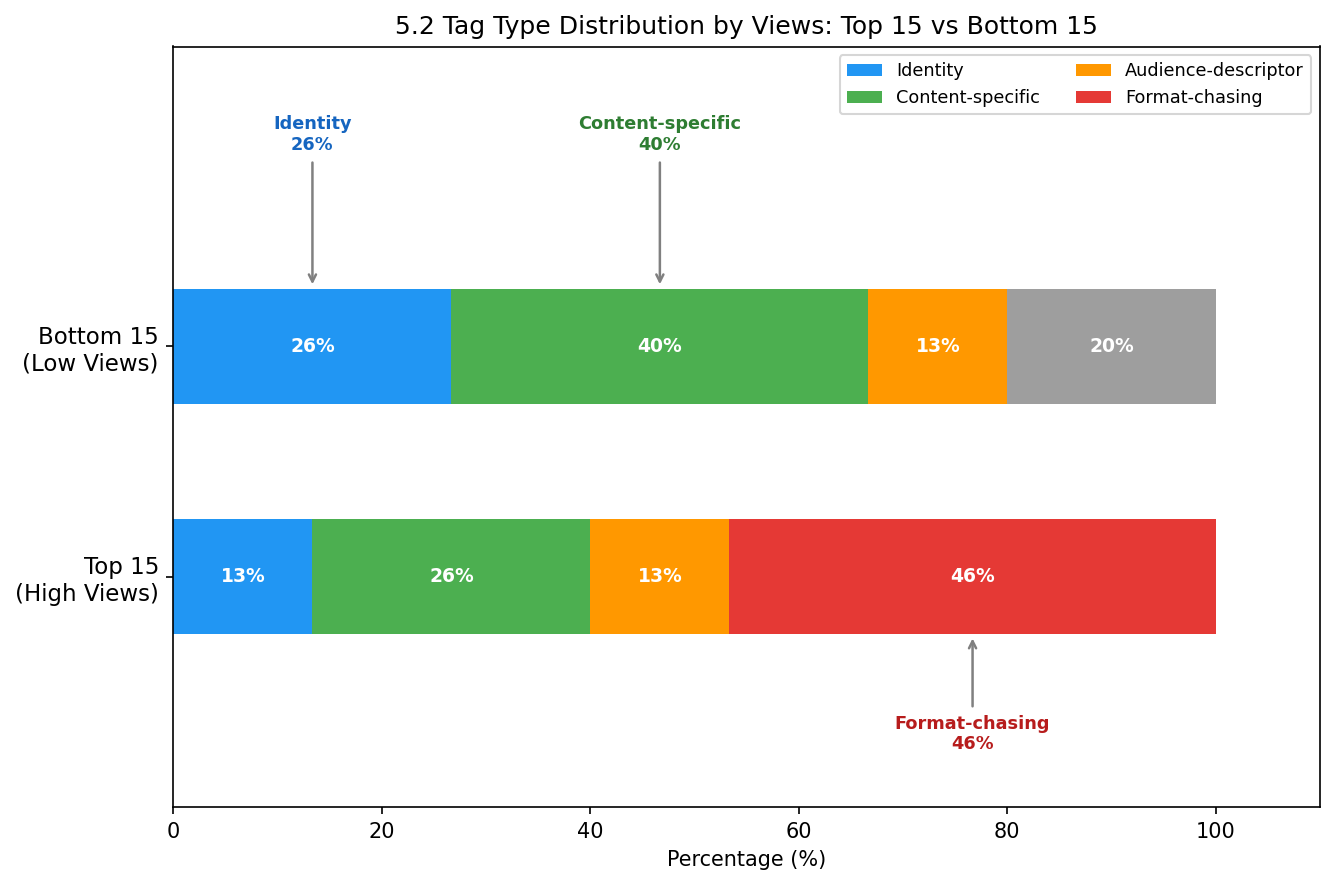

Saved: 5_2_tag_type_views_stacked.png


In [29]:
# ============================================================
# Chapter 5: Tag Strategy Analysis
# Step 2 — 5.2 Part A (Extended): Views dimension stacked bar
# ============================================================

# Label top/bottom 15 by views
top15_views_types = {
    'youtubegrowth': 'Identity',
    'youtubeshorts': 'Format-chasing',
    'shorts':        'Format-chasing',
    'art':           'Content-specific',
    'funnyvlog':     'Content-specific',
    'minivlogs':     'Format-chasing',
    'trendingvideo': 'Format-chasing',
    'viralshort':    'Format-chasing',
    'smallyoutuber': 'Identity',
    'students':      'Audience-descriptor',
    'trend':         'Format-chasing',
    'short':         'Format-chasing',
    'collegelife':   'Audience-descriptor',
    'viralvlog':     'Content-specific',
    'live':          'Content-specific',
}

bot15_views_types = {
    'mini':          'Ambiguous',
    'smallcreator':  'Identity',
    'firstvideo':    'Identity',
    'newchannel':    'Identity',
    'support':       'Ambiguous',
    'video':         'Ambiguous',
    'simplelife':    'Identity',
    'vlogvideo':     'Content-specific',
    'reelsindia':    'Content-specific',
    'music':         'Content-specific',
    'life':          'Content-specific',
    'gaming':        'Content-specific',
    'youtubeindia':  'Audience-descriptor',
    'india':         'Audience-descriptor',
    'vlogging':      'Content-specific',
}

top15_views_df = pd.DataFrame(list(top15_views_types.items()), columns=['tag','type'])
bot15_views_df = pd.DataFrame(list(bot15_views_types.items()), columns=['tag','type'])

all_types = ['Identity','Content-specific','Audience-descriptor','Format-chasing','Ambiguous']
colors    = ['#2196F3','#4CAF50','#FF9800','#E53935','#9E9E9E']

top_dist = top15_views_df['type'].value_counts()
bot_dist = bot15_views_df['type'].value_counts()

comp_views = pd.DataFrame({
    'Top 15 %':    [(top_dist.get(t,0)/15*100) for t in all_types],
    'Bottom 15 %': [(bot_dist.get(t,0)/15*100) for t in all_types]
}, index=all_types)

print("Views — Type distribution comparison:")
print(comp_views.to_string())

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 6))

bar_pos = [0.2, 1.2]
groups  = ['Top 15\n(High Views)', 'Bottom 15\n(Low Views)']
data    = [comp_views['Top 15 %'].tolist(), comp_views['Bottom 15 %'].tolist()]

top_positions = {}
bot_positions = {}

for i, (pos, pcts) in enumerate(zip(bar_pos, data)):
    left = 0
    for j, (pct, color, ttype) in enumerate(zip(pcts, colors, all_types)):
        if pct > 0:
            ax.barh(pos, pct, left=left, color=color,
                    label=ttype if i == 0 else "", height=0.5)
            if pct >= 8:
                ax.text(left + pct/2, pos, f'{int(pct)}%',
                        ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            center_x = left + pct/2
            if i == 0:
                top_positions[ttype] = (center_x, pct)
            else:
                bot_positions[ttype] = (center_x, pct)
            left += pct

# Top 15 annotations — BELOW
for ttype, ann_color in [('Format-chasing','#B71C1C')]:
    if ttype in top_positions:
        cx, pct = top_positions[ttype]
        ax.annotate(f'{ttype}\n{int(pct)}%',
                    xy=(cx, bar_pos[0] - 0.25),
                    xytext=(cx, bar_pos[0] - 0.75),
                    ha='center', fontsize=8.5,
                    color=ann_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Bottom 15 annotations — ABOVE
for ttype, ann_color in [('Identity','#1565C0'), ('Content-specific','#2E7D32')]:
    if ttype in bot_positions:
        cx, pct = bot_positions[ttype]
        ax.annotate(f'{ttype}\n{int(pct)}%',
                    xy=(cx, bar_pos[1] + 0.25),
                    xytext=(cx, bar_pos[1] + 0.85),
                    ha='center', fontsize=8.5,
                    color=ann_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.set_yticks(bar_pos)
ax.set_yticklabels(groups, fontsize=11)
ax.set_xlabel('Percentage (%)')
ax.set_xlim(0, 110)
ax.set_ylim(-0.8, 2.5)
ax.set_title('5.2 Tag Type Distribution by Views: Top 15 vs Bottom 15')
ax.legend(loc='upper right', fontsize=8.5, ncol=2)

plt.tight_layout()
plt.savefig('5_2_tag_type_views_stacked.png', bbox_inches='tight')
plt.show()
print("Saved: 5_2_tag_type_views_stacked.png")

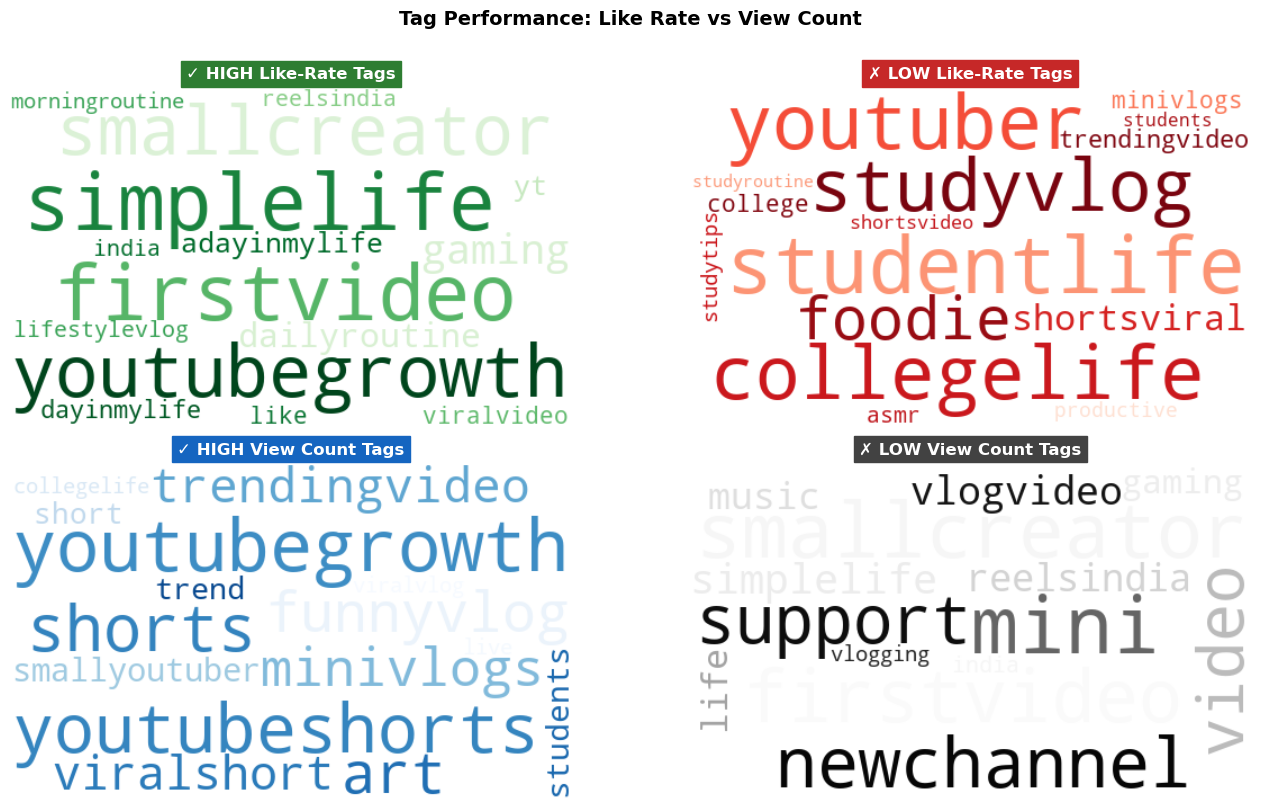

Saved: 5_2_wordcloud_4panel.png


In [1]:
# ============================================================
# Chapter 5: Tag Strategy Analysis
# Step 2 — Word Cloud: High vs Low Like Rate + Views
# ============================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ── Like Rate dimension ──
top15_lr_freq = {
    'simplelife': 1577, 'firstvideo': 1513, 'youtubegrowth': 1290,
    'smallcreator': 1153, 'gaming': 1114, 'dailyroutine': 1055,
    'adayinmylife': 921, 'yt': 913, 'dayinmylife': 876,
    'viralvideo': 834, 'like': 834, 'lifestylevlog': 833,
    'reelsindia': 825, 'india': 823, 'morningroutine': 812
}

bot15_lr_freq = {
    'studyroutine': 73, 'students': 79, 'shortsvideo': 87,
    'productive': 101, 'studytips': 103, 'asmr': 109,
    'minivlogs': 119, 'college': 120, 'trendingvideo': 127,
    'shortsviral': 131, 'foodie': 140, 'studyvlog': 143,
    'youtuber': 153, 'collegelife': 153, 'studentlife': 167
}

# ── Views dimension ──
top15_views_freq = {
    'youtubegrowth': 900, 'youtubeshorts': 800, 'shorts': 750,
    'art': 600, 'funnyvlog': 580, 'minivlogs': 560,
    'trendingvideo': 540, 'viralshort': 520, 'smallyoutuber': 500,
    'students': 480, 'trend': 460, 'short': 440,
    'collegelife': 420, 'viralvlog': 400, 'live': 380
}

bot15_views_freq = {
    'mini': 400, 'smallcreator': 380, 'firstvideo': 360,
    'newchannel': 340, 'support': 320, 'video': 300,
    'simplelife': 280, 'vlogvideo': 260, 'reelsindia': 240,
    'music': 220, 'life': 200, 'gaming': 180,
    'youtubeindia': 160, 'india': 140, 'vlogging': 120
}

def make_wordcloud(freq, colormap):
    return WordCloud(
        width=500, height=300,
        background_color='white',
        colormap=colormap,
        min_font_size=10,
        max_font_size=70,
        prefer_horizontal=0.8
    ).generate_from_frequencies(freq)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

configs = [
    (top15_lr_freq,    'Greens', '✓ HIGH Like-Rate Tags',  '#2E7D32', axes[0][0]),
    (bot15_lr_freq,    'Reds',   '✗ LOW Like-Rate Tags',   '#C62828', axes[0][1]),
    (top15_views_freq, 'Blues',  '✓ HIGH View Count Tags', '#1565C0', axes[1][0]),
    (bot15_views_freq, 'Greys',  '✗ LOW View Count Tags',  '#424242', axes[1][1]),
]

for freq, cmap, title, bg, ax in configs:
    wc = make_wordcloud(freq, cmap)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold',
                 color='white', backgroundcolor=bg, pad=8)

plt.suptitle('Tag Performance: Like Rate vs View Count', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('5_2_wordcloud_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 5_2_wordcloud_4panel.png")

### 5.2.2：Association rules by quadrant

In [31]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

def run_rules_quadrant(df, label, min_sup=0.025, min_lift=1.3):
    tag_lists = [tags for tags in df['hashtag_list'] if len(tags) > 1]
    print(f"\n[{label}]")
    print(f"  Total videos: {len(df)}, with 2+ hashtags: {len(tag_lists)}")
    
    if len(tag_lists) < 20:
        print("  Not enough data")
        return None
    
    te = TransactionEncoder()
    te_arr = te.fit_transform(tag_lists)
    te_df = pd.DataFrame(te_arr, columns=te.columns_)
    
    # Drop rare columns
    col_sup = te_df.mean()
    te_df = te_df[col_sup[col_sup >= min_sup].index]
    
    if te_df.shape[1] < 2:
        print("  Not enough frequent tags")
        return None
    
    freq = apriori(te_df, min_support=min_sup, use_colnames=True)
    if len(freq) == 0:
        print("  No frequent itemsets")
        return None
    
    rules = association_rules(freq, metric='lift', 
                              min_threshold=min_lift, 
                              num_itemsets=len(freq))
    rules = rules.sort_values('lift', ascending=False)
    print(f"  Rules found: {len(rules)}")
    
    if len(rules) > 0:
        top = rules.head(5).copy()
        top['ant'] = top['antecedents'].apply(lambda x: list(x))
        top['con'] = top['consequents'].apply(lambda x: list(x))
        print(top[['ant','con','support','confidence','lift']].round(3).to_string(index=False))
    
    return rules

golden_videos       = micro[micro['quadrant'] == 'Golden']
exposure_trap_videos = micro[micro['quadrant'] == 'Exposure Trap']
niche_videos        = micro[micro['quadrant'] == 'Niche']

rules_golden   = run_rules_quadrant(golden_videos,        "Golden (high views + high like rate)")
rules_exposure = run_rules_quadrant(exposure_trap_videos, "Exposure Trap (high views + low like rate)")
rules_niche    = run_rules_quadrant(niche_videos,         "Niche (low views + high like rate)")


[Golden (high views + high like rate)]
  Total videos: 226, with 2+ hashtags: 186
  Rules found: 432
                        ant                      con  support  confidence   lift
           [trendingshorts]                  [reels]    0.027       0.556 17.222
                    [reels]         [trendingshorts]    0.027       0.833 17.222
   [shorts, whatieatinaday]                   [food]    0.027       0.833 12.917
                     [food] [shorts, whatieatinaday]    0.027       0.417 12.917
[vlog, dailyvlog, minivlog]           [dailyroutine]    0.027       0.556 12.917

[Exposure Trap (high views + low like rate)]
  Total videos: 292, with 2+ hashtags: 270
  Rules found: 1558
                       ant                        con  support  confidence   lift
[dailyvlog, lifestylevlog]            [indianvlogger]    0.026       0.875 23.625
           [indianvlogger] [dailyvlog, lifestylevlog]    0.026       0.700 23.625
           [lifestylevlog] [dailyvlog, indianvlogger]    

In [32]:
# ============================================================
# Chapter 5: Tag Strategy Analysis
# Appendix — Full Association Rules by Quadrant
# ============================================================

def format_rules_for_appendix(rules, label, n=10):
    if rules is None or len(rules) == 0:
        print(f"\n{label}: No rules found")
        return None
    
    top = rules.head(n).copy()
    top['antecedents'] = top['antecedents'].apply(lambda x: ', '.join(list(x)))
    top['consequents'] = top['consequents'].apply(lambda x: ', '.join(list(x)))
    top = top[['antecedents','consequents','support','confidence','lift']].round(3)
    top.columns = ['Antecedent','Consequent','Support','Confidence','Lift']
    top.index = range(1, len(top)+1)
    
    print(f"\nTable: Association Rules — {label} (top {n} by lift)")
    print("-" * 75)
    print(top.to_string())
    print("-" * 75)
    return top

golden_app   = format_rules_for_appendix(rules_golden,   "Golden zone (high views + high like rate)")
exposure_app = format_rules_for_appendix(rules_exposure,  "Exposure Trap zone (high views + low like rate)")
niche_app    = format_rules_for_appendix(rules_niche,     "Niche zone (low views + high like rate)")

# ── Export to CSV ──
import os
if golden_app is not None:
    golden_app.to_csv('appendix_rules_golden.csv')
if exposure_app is not None:
    exposure_app.to_csv('appendix_rules_exposure_trap.csv')
if niche_app is not None:
    niche_app.to_csv('appendix_rules_niche.csv')

print("\nExported:")
print("  appendix_rules_golden.csv")
print("  appendix_rules_exposure_trap.csv")
print("  appendix_rules_niche.csv")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Table: Association Rules — Golden zone (high views + high like rate) (top 10 by lift)
---------------------------------------------------------------------------
                   Antecedent                 Consequent  Support  Confidence    Lift
1              trendingshorts                      reels    0.027       0.556  17.222
2                       reels             trendingshorts    0.027       0.833  17.222
3      shorts, whatieatinaday                       food    0.027       0.833  12.917
4                        food     shorts, whatieatinaday    0.027       0.417  12.917
5   vlog, dailyvlog, minivlog               dailyroutine    0.027       0.556  12.917
6                dailyroutine  vlog, dailyvlog, minivlog    0.027       0.625  12.917
7      dailyroutine, minivlog            dailyvlog, vlog    0.027       0.714  11.

### 5.3 Does Hashtag Quantity Matter?

This section tests two assumptions: first, whether more hashtags lead to higher views (discoverability hypothesis); second, whether more hashtags lead to higher like rate (audience fit hypothesis). Views and like rate are analyzed separately to distinguish between the two mechanisms.

平台推送机制的三个层级：

Tier 1 — Basic Traffic (Available for all videos)
YouTube provides a certain amount of initial promotion for every newly uploaded video, allowing the algorithm to gauge audience response. During this stage, hashtags may be of some help in assisting the algorithm to make an initial assessment of the video’s category.

Tier 2— Engagement-Driven Traffic (Driven by Like Rate)
The algorithm determines whether to continue expanding the reach based on engagement metrics (like rate, comment rate, and completion rate) during the initial promotion phase. The higher the like rate, the more likely the algorithm is to continue promoting the video. Therefore, if hashtags attract an irrelevant audience resulting in a low like rate, the algorithm will deem the video ‘not good enough’ and reduce subsequent promotion.

Tier 3— Subscriber-Based Traffic (Subscriber-Driven)
The more subscribers you have, the greater the baseline traffic directly pushed to your followers upon video release, allowing you to gain substantial initial exposure without relying on hashtags. This explains why large channels with many hashtags also have high view counts — they already possess a substantial subscriber base, and hashtags merely serve as an additional bonus.

For micro-creators, lacking a subscriber base means they rely entirely on traffic from the first and second tiers.
If too many hashtags are used to attract an irrelevant audience, the first-tier traffic may be substantial but the like rate will be low; consequently, the second-tier traffic will not materialise. Ultimately, the total exposure may be lower than that of a video using a small number of targeted hashtags — the latter, whilst having lower initial traffic, boasts a high like rate, prompting the algorithm to continue boosting its distribution.

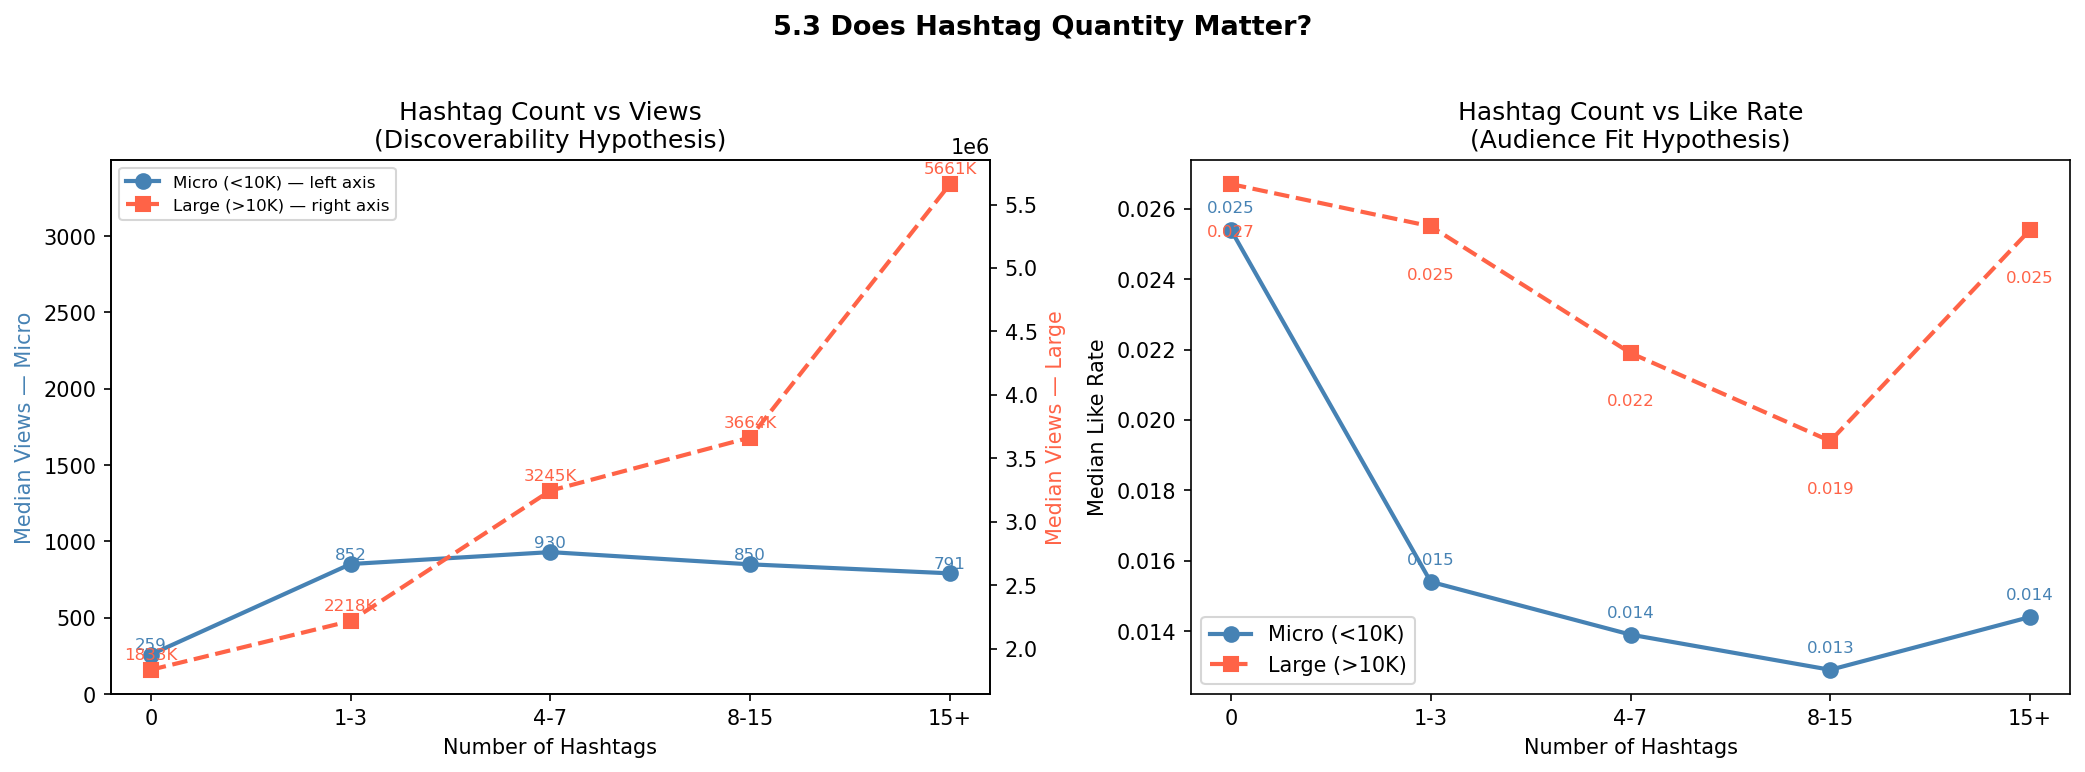

Saved: 5_3_hashtag_quantity_final.png


In [24]:
# ── Plot with fixed left y-axis ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Views — dual y-axis, micro fixed 0-4000
ax1 = axes[0]
ax1_right = ax1.twinx()

ax1.plot(labels, micro_views['median_views'], marker='o', color='steelblue',
         linewidth=2, markersize=7, label='Micro (<10K) — left axis')
ax1_right.plot(labels, large_views['median_views'], marker='s', color='tomato',
               linewidth=2, markersize=7, label='Large (>10K) — right axis', linestyle='--')

for i, m in enumerate(micro_views['median_views']):
    ax1.text(i, m + 30, f'{int(m)}', ha='center', fontsize=8, color='steelblue')
for i, l in enumerate(large_views['median_views']):
    ax1_right.text(i, l + 80000, f'{int(l/1000)}K', ha='center', fontsize=8, color='tomato')

ax1.set_ylim(0, 3500)
ax1.set_yticks(range(0, 3500, 500))
ax1.set_xlabel('Number of Hashtags')
ax1.set_ylabel('Median Views — Micro', color='steelblue')
ax1_right.set_ylabel('Median Views — Large', color='tomato')
ax1.set_title('Hashtag Count vs Views\n(Discoverability Hypothesis)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

# Right: Like Rate
axes[1].plot(labels, micro_result['median_lr'], marker='o', color='steelblue',
             linewidth=2, markersize=7, label='Micro (<10K)')
axes[1].plot(labels, large_result['median_lr'], marker='s', color='tomato',
             linewidth=2, markersize=7, label='Large (>10K)', linestyle='--')

for i, (m, l) in enumerate(zip(micro_result['median_lr'], large_result['median_lr'])):
    axes[1].text(i, m + 0.0005, f'{m:.3f}', ha='center', fontsize=8, color='steelblue')
    axes[1].text(i, l - 0.0015, f'{l:.3f}', ha='center', fontsize=8, color='tomato')

axes[1].set_xlabel('Number of Hashtags')
axes[1].set_ylabel('Median Like Rate')
axes[1].set_title('Hashtag Count vs Like Rate\n(Audience Fit Hypothesis)')
axes[1].legend()

plt.suptitle('5.3 Does Hashtag Quantity Matter?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('5_3_hashtag_quantity_final.png', bbox_inches='tight')
plt.show()
print("Saved: 5_3_hashtag_quantity_final.png")

In [17]:
# ── Export combined tables ──

# Views table (micro + large combined)
views_combined = pd.DataFrame({
    'hashtag_bin': labels,
    'micro_median_views': micro_views['median_views'].values,
    'micro_count': micro_views['count'].values,
    'large_median_views': large_views['median_views'].values,
    'large_count': large_views['count'].values
})
views_combined.to_csv('5_3_views_combined.csv', index=False)

# Like rate table (micro + large combined)
lr_combined = pd.DataFrame({
    'hashtag_bin': labels,
    'micro_median_lr': micro_result['median_lr'].values,
    'micro_count': micro_result['count'].values,
    'large_median_lr': large_result['median_lr'].values,
    'large_count': large_result['count'].values
})
lr_combined.to_csv('5_3_likerate_combined.csv', index=False)

print("Exported:")
print("  5_3_views_combined.csv")
print("  5_3_likerate_combined.csv")
print()
print(views_combined.to_string(index=False))
print()
print(lr_combined.to_string(index=False))

Exported:
  5_3_views_combined.csv
  5_3_likerate_combined.csv

hashtag_bin  micro_median_views  micro_count  large_median_views  large_count
          0               259.0          171           1833736.0          443
        1-3               852.0          163           2218797.0          306
        4-7               930.0          268           3245543.0          267
       8-15               850.0          242           3664175.0          105
        15+               791.0          181           5661214.0           50

hashtag_bin  micro_median_lr  micro_count  large_median_lr  large_count
          0           0.0254          171           0.0267          443
        1-3           0.0154          163           0.0255          306
        4-7           0.0139          268           0.0219          267
       8-15           0.0129          242           0.0194          105
        15+           0.0144          181           0.0254           50


### Summary

In [25]:
print("=" * 65)
print("CHAPTER 5: TAG STRATEGY ANALYSIS — SUMMARY")
print("=" * 65)

print("\n[5.1] TWO-DIMENSIONAL FRAMEWORK (Micro dataset)")
print("-" * 65)
quad_dist = micro['quadrant'].value_counts()
total = len(micro)
for q, n in quad_dist.items():
    print(f"  {q:<20} {n:>4} videos ({round(n/total*100,1)}%)")

print("\n[5.2] TAG TYPE DISTRIBUTION: TOP 15 VS BOTTOM 15")
print("-" * 65)
print(f"  {'Type':<25} {'Top 15':>8} {'Bottom 15':>10}")
print("  " + "-" * 45)
for t in all_types:
    tp = comp.loc[t, 'Top 15 %']
    bp = comp.loc[t, 'Bottom 15 %']
    print(f"  {t:<25} {tp:>6}%   {bp:>7}%")

print("\n[5.3] HASHTAG QUANTITY (Micro)")
print("-" * 65)
print(f"  {'Hashtag Count':<15} {'Median LR':>10} {'Median Views':>14} {'n':>6}")
for idx in labels:
    lr  = micro_result.loc[idx, 'median_lr']
    v   = micro_views.loc[idx, 'median_views']
    n   = int(micro_result.loc[idx, 'count'])
    print(f"  {idx:<15} {lr:>10.4f} {int(v):>14,} {n:>6}")

print(f"\n  Pearson correlation (LR):  r={round(corr_p,4)},  p={round(p_p,4)}")
print(f"  Spearman correlation (LR): r={round(corr_s,4)}, p={round(p_s,4)}")
print(f"  Partial correlation (LR):  r={round(corr_pc,4)}, p={round(p_pc,4)}")
print(f"  Views correlation:         r={round(corr_v,4)},  p={round(p_v,4)}")
print(f"\n  Without hashtags: median LR={round(no,4)}, n={micro[micro['hashtag_list'].apply(len)==0].shape[0]}")
print(f"  With hashtags:    median LR={round(has,4)}, n={micro[micro['hashtag_list'].apply(len)>0].shape[0]}")
print(f"  Difference:       +{diff}% higher without hashtags")

print("\n[RECOMMENDATIONS]")
print("-" * 65)
print("  1. Prioritize Identity + Content-specific tags")
print("     74% of top-performing tags vs 20% of bottom-performing tags")
print("  2. Avoid Audience-descriptor + Format-chasing tags")
print("     80% of bottom-performing tags vs 13% of top-performing tags")
print("  3. Use 0-3 hashtags")
print("     No significant independent effect on like rate (partial r=-0.023, p=0.461)")
print("     Trade-off: more hashtags slightly increases views but reduces like rate")
print("=" * 65)

# ── Export full summary to CSV ──
summary_data = {
    'section': [],
    'metric': [],
    'value': []
}

# 5.2
for t in all_types:
    summary_data['section'].append('5.2')
    summary_data['metric'].append(f'Top15_{t}_%')
    summary_data['value'].append(comp.loc[t, 'Top 15 %'])
    summary_data['section'].append('5.2')
    summary_data['metric'].append(f'Bottom15_{t}_%')
    summary_data['value'].append(comp.loc[t, 'Bottom 15 %'])

# 5.3
summary_data['section'] += ['5.3','5.3','5.3','5.3','5.3']
summary_data['metric']  += ['Pearson_r','Pearson_p','Spearman_r','Spearman_p','Partial_r']
summary_data['value']   += [round(corr_p,4), round(p_p,4), round(corr_s,4), round(p_s,4), round(corr_pc,4)]

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('5_chapter_summary.csv', index=False)
print("\nExported: 5_chapter_summary.csv")

CHAPTER 5: TAG STRATEGY ANALYSIS — SUMMARY

[5.1] TWO-DIMENSIONAL FRAMEWORK (Micro dataset)
-----------------------------------------------------------------
  Niche                 292 videos (28.2%)
  Exposure Trap         292 videos (28.2%)
  Golden                226 videos (21.8%)
  Ineffective           225 videos (21.7%)

[5.2] TAG TYPE DISTRIBUTION: TOP 15 VS BOTTOM 15
-----------------------------------------------------------------
  Type                        Top 15  Bottom 15
  ---------------------------------------------
  Identity                      27%         7%
  Content-specific              47%        13%
  Audience-descriptor            7%        53%
  Format-chasing                 7%        27%
  Ambiguous                     13%         0%

[5.3] HASHTAG QUANTITY (Micro)
-----------------------------------------------------------------
  Hashtag Count    Median LR   Median Views      n
  0                   0.0254            259    171
  1-3                 0